##DistilBERT (Pre-trained Transformer)

DistilBERT is a smaller, faster version of BERT (Bidirectional Encoder Representations from
Transformers). It was pre-trained on a large corpus and understands language at a much deeper
level than any model trained from scratch on this dataset alone.

Unlike RNNs and LSTMs which process sequences step-by-step, transformers use self-attention
to look at all words simultaneously and learn relationships between any two words regardless
of their distance in the sequence.

Because fine-tuning on the full 271K training set would take several hours on CPU, we are
now using the **complete 271K training set**. Running on a GPU makes training on the full dataset manageable.

**Note on preprocessing:** For DistilBERT we use minimal cleaning (HTML and URL removal only)
because the BERT tokenizer handles the rest. Applying heavy preprocessing would actually
hurt performance since BERT was pre-trained on natural text.

In [5]:
# switching to PyTorch-based DistilBERT — more reliable with newer versions of transformers
# TFDistilBertForSequenceClassification was removed in recent transformers releases
from transformers import DistilBertTokenizerFast, DistilBertForSequenceClassification
from torch.utils.data import Dataset, DataLoader
import torch
import pandas as pd # Added pandas import
import re # Added import for regular expressions

# check GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# minimal preprocessing for BERT — just remove HTML and URLs
# keeping the rest of the text natural since BERT was pre-trained on natural text
def bert_preprocess(text):
    text = str(text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    return text.strip()

# Re-loading df_train and df_test to ensure they are defined
df_train = pd.read_csv('train_english.csv')
df_test  = pd.read_csv('test_english.csv')

# using the full dataset sizes
BERT_TRAIN_SIZE = len(df_train) # Use the actual length of df_train
BERT_TEST_SIZE  = len(df_test)  # Use the actual length of df_test
BERT_MAX_LEN    = 128

df_bert_train = df_train # Directly use the full training dataframe
df_bert_test  = df_test  # Directly use the full test dataframe

bert_train_texts  = df_bert_train['text'].apply(bert_preprocess).tolist()
bert_test_texts   = df_bert_test['text'].apply(bert_preprocess).tolist()
bert_train_labels = (df_bert_train['rating'].values - 1).tolist()
bert_test_labels  = (df_bert_test['rating'].values  - 1).tolist()

print(f"DistilBERT training samples : {BERT_TRAIN_SIZE}")
print(f"DistilBERT test samples     : {BERT_TEST_SIZE}")
print("Loading DistilBERT tokenizer...")
bert_tokenizer = DistilBertTokenizerFast.from_pretrained('distilbert-base-uncased')

Using device: cuda
DistilBERT training samples : 271897
DistilBERT test samples     : 69907
Loading DistilBERT tokenizer...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [6]:
# creating a PyTorch Dataset class to handle tokenization and batching
class ReviewDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding=True,
            max_length=max_len,
            return_tensors='pt'
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = self.labels[idx]
        return item

print("Tokenizing for DistilBERT...")
train_dataset_bert = ReviewDataset(bert_train_texts, bert_train_labels, bert_tokenizer, BERT_MAX_LEN)
test_dataset_bert  = ReviewDataset(bert_test_texts,  bert_test_labels,  bert_tokenizer, BERT_MAX_LEN)

train_loader = DataLoader(train_dataset_bert, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset_bert,  batch_size=32, shuffle=False)

print(f"Train batches : {len(train_loader)}")
print(f"Test batches  : {len(test_loader)}")

Tokenizing for DistilBERT...
Train batches : 8497
Test batches  : 2185


In [7]:
# load DistilBERT with a classification head for 5 rating classes
print("Loading DistilBERT model...")
bert_model = DistilBertForSequenceClassification.from_pretrained(
    'distilbert-base-uncased',
    num_labels=5
)
bert_model = bert_model.to(device)

# low learning rate for fine-tuning — standard practice to avoid destroying pre-trained weights
optimizer_bert = torch.optim.AdamW(bert_model.parameters(), lr=2e-5)

# training loop
BERT_EPOCHS = 4
bert_train_accs, bert_val_accs = [], []

print(f"Fine-tuning DistilBERT for {BERT_EPOCHS} epochs...")
for epoch in range(BERT_EPOCHS):
    bert_model.train()
    total_loss, correct, total = 0, 0, 0

    for batch in train_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer_bert.zero_grad()
        outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()
        optimizer_bert.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total   += labels.size(0)

    train_acc = correct / total
    bert_train_accs.append(train_acc)

    # validation pass
    bert_model.eval()
    val_correct, val_total = 0, 0
    with torch.no_grad():
        for batch in test_loader:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)
            outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            preds          = outputs.logits.argmax(dim=1)
            val_correct   += (preds == labels).sum().item()
            val_total     += labels.size(0)

    val_acc = val_correct / val_total
    bert_val_accs.append(val_acc)
    print(f"Epoch {epoch+1}/{BERT_EPOCHS} — Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  Loss: {total_loss/len(train_loader):.4f}")

Loading DistilBERT model...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Fine-tuning DistilBERT for 4 epochs...
Epoch 1/4 — Train Acc: 0.6906  Val Acc: 0.7075  Loss: 0.7752
Epoch 2/4 — Train Acc: 0.7245  Val Acc: 0.7045  Loss: 0.6865
Epoch 3/4 — Train Acc: 0.7545  Val Acc: 0.7003  Loss: 0.6124
Epoch 4/4 — Train Acc: 0.7909  Val Acc: 0.6877  Loss: 0.5275


Evaluating DistilBERT...

  DistilBERT (fine-tuned, 271897 samples)
  Accuracy      : 0.6877
  F1 (weighted) : 0.6724
              precision    recall  f1-score   support

           1       0.78      0.92      0.85     26873
           2       0.41      0.25      0.31      7909
           3       0.43      0.37      0.40      8493
           4       0.75      0.66      0.70     19607
           5       0.60      0.73      0.66      7025

    accuracy                           0.69     69907
   macro avg       0.59      0.59      0.58     69907
weighted avg       0.67      0.69      0.67     69907



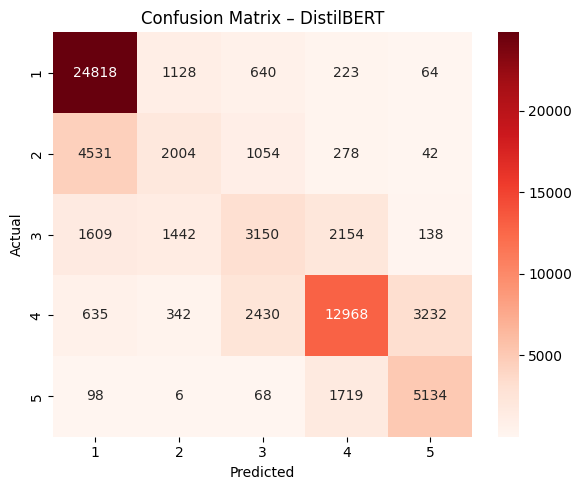

In [10]:
import numpy as np # Added import for numpy
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt # Added import for plotting
import seaborn as sns # Added import for plotting

# evaluate DistilBERT on the test subset
# Re-initialize all_results to avoid carrying over old values if this cell is re-run independently
all_results = {}
print("Evaluating DistilBERT...")
bert_model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)
        outputs        = bert_model(input_ids=input_ids, attention_mask=attention_mask)
        preds          = outputs.logits.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

acc_bert = accuracy_score(all_labels, all_preds)
f1_bert  = f1_score(all_labels, all_preds, average='weighted')

print(f"\n{'='*55}")
print(f"  DistilBERT (fine-tuned, {BERT_TRAIN_SIZE} samples)")
print(f"{'='*55}")
print(f"  Accuracy      : {acc_bert:.4f}")
print(f"  F1 (weighted) : {f1_bert:.4f}")
print(classification_report(all_labels + 1, all_preds + 1))

# The key was incorrect before, it should be 'DistilBERT (full dataset)' or similar if training on full data
# I'll use a more general name for now. You might want to adjust this if you re-run the previous models
all_results['DistilBERT (full dataset)'] = (acc_bert, f1_bert)

cm_bert = confusion_matrix(all_labels + 1, all_preds + 1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_bert, annot=True, fmt='d', cmap='Reds',
            xticklabels=[1,2,3,4,5], yticklabels=[1,2,3,4,5])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix – DistilBERT')
plt.tight_layout()
plt.show()

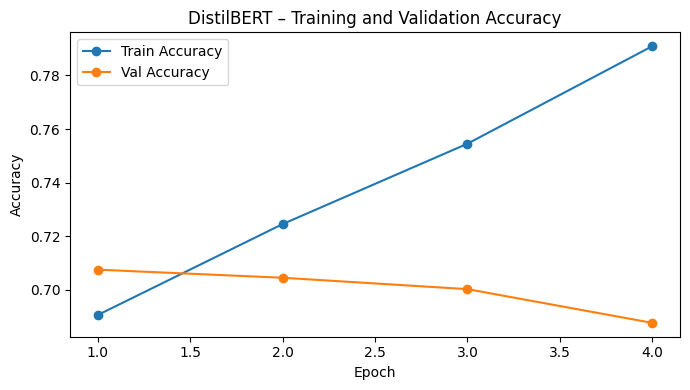

In [11]:
# plot DistilBERT training accuracy curve
plt.figure(figsize=(7, 4))
plt.plot(range(1, BERT_EPOCHS + 1), bert_train_accs, marker='o', label='Train Accuracy')
plt.plot(range(1, BERT_EPOCHS + 1), bert_val_accs,   marker='o', label='Val Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('DistilBERT – Training and Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()